# Forward Propagation with multiple Samples at once

Until now we just did forward propagation with one example (represented by a feature vector x). In forward propagation we had 
* matrix-vector multiplications in the linear combination layer (Dense layer) 
* elementwise sigmoid in the activation layer (Sigmoid Layer)

We now want to see if we can get a whole batch of training examples through the network in one pass. The data is stored in out sample maxtrix $X$ with dimensions $(samples$ $x$ $features)$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time as time
print("All imported")


All imported


## This is what we want to implement 
This time instead of feeding a a vector $x$ we waht to feed a whole matrix of samples $X$ with X.shape = (Samples, features) 

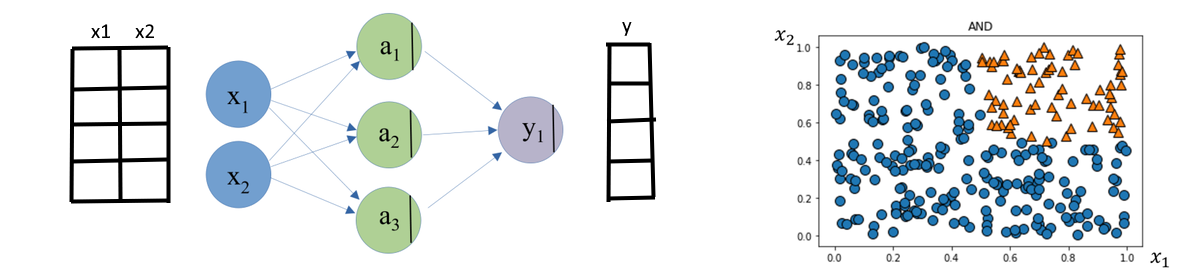

## Classes that may stay the same

In [2]:
class Layer:
    """
    An identity Layer to be the base of inheritance
    """
    def __init__(self):
        pass
    
    def forward(self, input):
        # identity, same output as input
        return input

In [3]:
class Sigmoid(Layer):
    def __init__(self):
        pass
    
    def forward(self, input):
        """Apply elementwise sigmoid to [batch, input_units] matrix"""
        return 1/(1 + np.exp(-input))
    
    def __str__(self):
        return "Sigmoid layer"

## Adapting the code of the Layers

For the single training example code we dot-multiplied the feature vector from the right to the matrix . When we feed a sample matrix with dimension $(samples$ $x$ $features)$ we have to rethink the forward function.
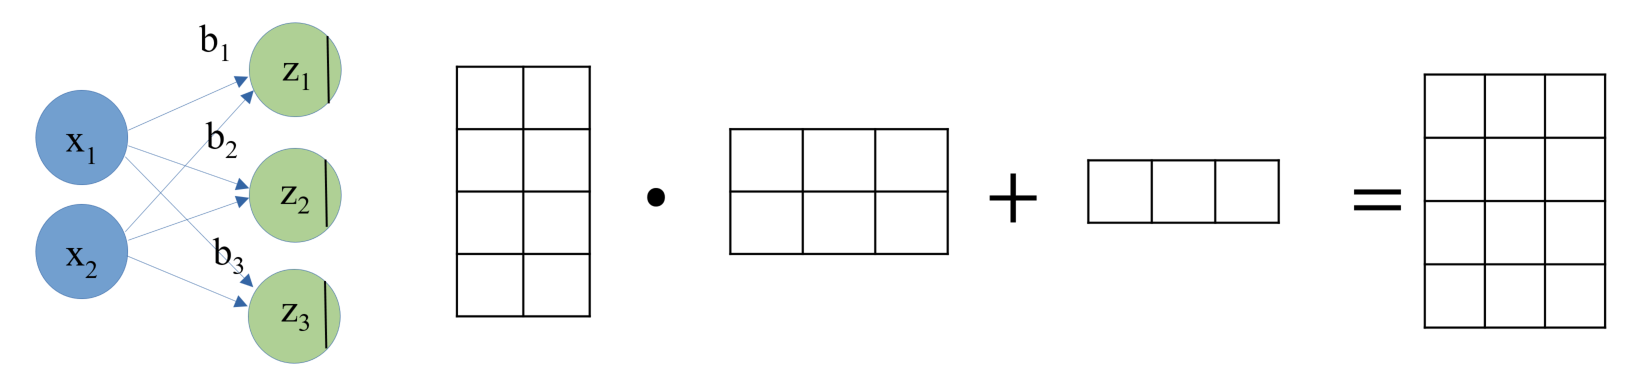

In [4]:
# An improved version compared to the last jupyter notebook
class Dense(Layer):
    def __init__(self, input_units, output_units, weights=None, biases=None):
        # initialize weights with small random numbers. We use normal initialization,
        if weights is None:
            self.weights = np.random.randn(input_units, output_units)*0.01
        else: 
            self.weights = weights
        if biases is None:
            self.biases = np.zeros(output_units)
        else:
            self.biases = biases
        
    def forward(self,input):
        return np.dot(input, self.weights)+self.biases
    
    def __str__(self):
        return f"Dense layer ({self.weights.shape})"

![](attachment:grafik2.png)
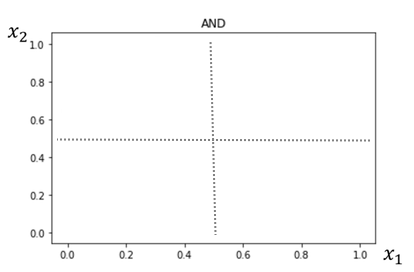
## Testing layer with example data 

In [5]:
# creating the data 4 examples
x1 = np.array([0.6,0.4]) # negative class
x2 = np.array([0.8,0.1]) # negative class
x3 = np.array([0.1,0.8]) # negative class
x4 = np.array([0.8,0.8]) # positive class
X = np.array([x1,x2,x3,x4]) 
y = np.array([0,0,0,1]) 
X,y

(array([[0.6, 0.4],
        [0.8, 0.1],
        [0.1, 0.8],
        [0.8, 0.8]]),
 array([0, 0, 0, 1]))

In [6]:
# creating the first layer and feed data
layer = Dense(2,3)
Sigmoid().forward(layer.forward(X))

array([[0.50053033, 0.50005741, 0.49740243],
       [0.50071682, 0.4999885 , 0.4983642 ],
       [0.50007195, 0.50015858, 0.49647418],
       [0.50070114, 0.50013074, 0.49541196]])

## Adapting the code for the Network

* Now batches should be treated instead of samples.
* Make the Network class more generic. Ideally to change the network structure just modifications in init are necessary without having to change the predict-function.
* Loss function needs to calculate the average loss for the batch

In [7]:
# An improved version of the network
class Network:
    def __init__(self): 
        self.layers = []
        self.layers.append(Dense(2,3, np.array([[1000,0],[0,1000],[0,0]]).T, np.array([-500,-500,0])))
        self.layers.append(Sigmoid())
        self.layers.append(Dense(3,1, np.array([[10, 10, 0]]).T, np.array([-18])))
        self.layers.append(Sigmoid())
        
    def predict(self, input, verbose=False):
        for layer in self.layers:
            input = layer.forward(input)
            if verbose: 
                print(f"Output of {layer} is {input.shape}")
        return input
    
    def __str__(self):
        text = "Network:\n"
        for layer in self.layers:
            text +=  f"{layer.__str__()}\n"
        return text
    
    def loss(self, y, pred):
        assert pred.shape == y.shape 
        vec = -np.log(pred)*y-(np.log(1-pred)*(1-y))
        return np.mean(vec);
    
print(Network())

Network:
Dense layer ((2, 3))
Sigmoid layer
Dense layer ((3, 1))
Sigmoid layer



## Vizualization

(20000,)


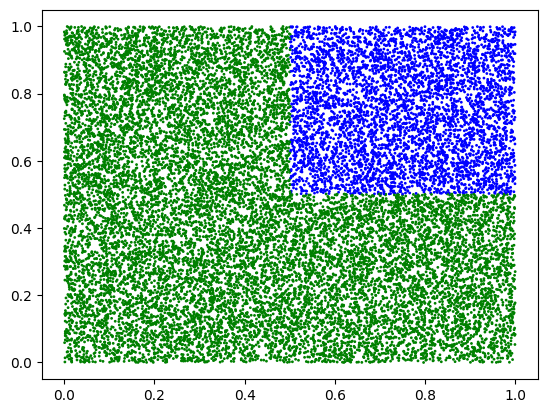

In [12]:
# Adapted Version of vizualizeDecisionBorder
def vizualizeDecisionBorder(net):
   samples = 20000
   X = np.random.rand(samples,2)
   #p = np.array([(net.predict(X[i])[0]) for i in range(samples)])  # this was the old line
   p=net.predict(X).reshape(-1,)                                    # this is the new line
   ptrue=(p>0.5)*1
   colorvec = np.array(["green","blue"])[ptrue]
   plt.scatter(X[:,0],X[:,1],c=colorvec,s=1)

net = Network()
vizualizeDecisionBorder(net)

## Speedcomparison

Create a larger batch of unlabeld test examples. Pass it through the network as a whole batch. . 

Finally add a time measurement with the function "time.time() and print the time used.".

In [13]:
samples = 300000
net = Network()
X = np.random.rand(samples,2) 
startTime = time.time()
print(X.shape)
# The old code that took 3.4 seconds was:
# for x in X:
#    p = net.predict(x)
p = net.predict(X)
endTime = time.time()
print("Used Time: ", endTime-startTime)

(300000, 2)
Used Time:  0.01562356948852539


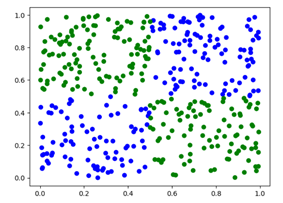

# Exercises

## Exercise 1 - XOR

Create a network that implements a xor logic, find network structure, weights and implement/debug the network. First start on Paper before you actually try to implement it.

In [16]:
net = Network()
net.layers = []
net.layers.append(Dense(2,4, np.array([[1000,0],[0,1000],[-1000,0],[0,-1000]]).T, np.array([-500,-500,500,500])))
net.layers.append(Sigmoid())
net.layers.append(Dense(4,2, np.array([[100,100,0,0],[0,0,100,100]]).T, np.array([-180,-180])))
net.layers.append(Sigmoid())
net.layers.append(Dense(2,1, np.array([[10, 10]]).T, np.array([-8])))
net.layers.append(Sigmoid())

You can debug with the following code. There is two types of input data, a larger set and a set of just one coordinate.

(20000,)


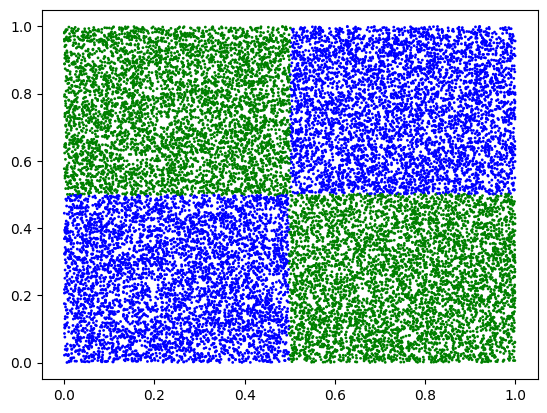

In [17]:
vizualizeDecisionBorder(net)

## Exercise 2
Can we also create any other logical operatores (Not, Or)